# makemore - MLP

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
# Build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X,Y = [], []
for w in words:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join([itos[i] for i in context]), '--->', itos[ix])

        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
char_embedding_size = 2

C = torch.randn((27,char_embedding_size))
C

tensor([[ 0.1115, -0.3807],
        [-2.5297,  0.8621],
        [-0.4996, -1.7825],
        [ 1.5801, -0.7463],
        [ 0.6472, -1.3046],
        [ 0.7180,  0.6768],
        [ 1.4144,  0.0344],
        [-0.1857, -0.5418],
        [ 0.0043, -0.0336],
        [-0.7660,  0.4108],
        [-0.4369,  1.2308],
        [ 0.8524, -0.8440],
        [-0.3652, -1.5186],
        [ 0.2207,  0.4984],
        [-1.3614, -1.6710],
        [-0.1311, -0.3631],
        [-0.2710, -0.3412],
        [-0.0530, -0.0922],
        [ 1.0312, -0.8699],
        [ 1.5376, -1.8431],
        [-1.4943,  0.6834],
        [ 0.0153, -0.6958],
        [ 0.0158, -0.9370],
        [-1.7171,  0.3833],
        [-0.8083, -0.1164],
        [-0.5457,  0.5570],
        [-1.6125, -0.3314]])

In [8]:
# We can index into tensors with multidimensional tensors

print("X[3]",X[3])
print("X[3] to letters", [itos[i.item()] for i in X[3]])
print("X[3] to embeddings using list comprehension", [C[i] for i in X[3]])
print("X[3] to embeddings using indexing", C[X[3]])

X[3] tensor([ 5, 13, 13])
X[3] to letters ['e', 'm', 'm']
X[3] to embeddings using list comprehension [tensor([0.7180, 0.6768]), tensor([0.2207, 0.4984]), tensor([0.2207, 0.4984])]
X[3] to embeddings using indexing tensor([[0.7180, 0.6768],
        [0.2207, 0.4984],
        [0.2207, 0.4984]])


In [9]:
emb = C[X]
emb.shape
# 32 examples with 3 letters with a 2 dim embedding per word

torch.Size([228146, 3, 2])

In [10]:
torch.cat(torch.unbind(emb, 1), 1).shape # removes a dimension then concats them to get the desired shape
                                         # Inefficient because it is creating an entirely new tensor

torch.Size([228146, 6])

In [11]:
X.shape

torch.Size([228146, 3])

In [12]:
# Instead, we compose a new view of the storage. This just creates a new arrangement of the same underlying data
emb.storage() # Views the underlying data

# emb.view(32, 6) # More efficient than previous method
emb.view(emb.shape[0], 6) #equivalent to ...view(-1, 6)

/var/folders/1w/83txp6k11cjbc4z0gsxz1vj40000gn/T/ipykernel_46207/2266150734.py:2: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  emb.storage() # Views the underlying data


tensor([[ 0.1115, -0.3807,  0.1115, -0.3807,  0.1115, -0.3807],
        [ 0.1115, -0.3807,  0.1115, -0.3807,  0.7180,  0.6768],
        [ 0.1115, -0.3807,  0.7180,  0.6768,  0.2207,  0.4984],
        ...,
        [-1.6125, -0.3314, -1.6125, -0.3314, -0.5457,  0.5570],
        [-1.6125, -0.3314, -0.5457,  0.5570, -1.6125, -0.3314],
        [-0.5457,  0.5570, -1.6125, -0.3314, -0.8083, -0.1164]])

In [13]:
hidden_layer_size = 100
total_embedding_size = block_size * char_embedding_size

W1 = torch.randn((total_embedding_size,hidden_layer_size))
b = torch.randn(hidden_layer_size)

In [14]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b)

In [15]:
output_size = 27

W2 = torch.randn((hidden_layer_size, output_size))
b2 = torch.randn(output_size)
logits = h @ W2 + b2

In [16]:
logits.shape

torch.Size([228146, 27])

In [17]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([228146, 27])

In [18]:
torch.arange(prob.shape[0])

tensor([     0,      1,      2,  ..., 228143, 228144, 228145])

In [19]:
prob[torch.arange(prob.shape[0]), Y] 
# arange gives us sequence 0 - d where d is an int. e.g. arange(4) gives us 0, 1, 2, 3
# Y is a tensor with the next character in a sequence as an int for each training example
# prob is the normalized probabilities predicted for each character as the next for the training character sequence 
# For each training example, we retrieve the probability for the true y value. 

tensor([3.1651e-07, 4.4980e-08, 7.4964e-01,  ..., 4.4441e-05, 4.1864e-08,
        2.9180e-12])

In [20]:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean() # Negative Log Likelihood (NLL)
loss

tensor(16.4211)

## Cleaned up version

In [21]:
# Consts
vocab_size = 27
char_embedding_size = 2
block_size = 3
input_layer_size = char_embedding_size * block_size
hidden_layer_size = 100
output_layer_size = vocab_size
learning_rate = 0.1
epochs = 10
batch_size = 32

In [22]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, char_embedding_size), generator=g)
W1 = torch.randn((input_layer_size, hidden_layer_size), generator=g)
b1 = torch.randn((hidden_layer_size), generator=g)
W2 = torch.randn((hidden_layer_size, output_layer_size), generator=g)
b2 = torch.randn((output_layer_size), generator=g)
parameters = [C, W1, b1, W2, b2]

In [23]:
# Total number of params
print("Total params: ",sum(p.nelement() for p in parameters))

Total params:  3481


In [24]:
for p in parameters:
    p.requires_grad = True

for i in range(epochs):
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (batch_size,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 +b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    for p in parameters:
        p.data += -learning_rate * p.grad

20.72801399230957
19.777053833007812
15.867593765258789
15.419219970703125
13.788897514343262
15.7183198928833
11.439568519592285
11.492315292358398
14.294713973999023
11.282316207885742


Without going through all the steps in the video, what was covered:
1. Finding the right learning rate
    - We want to find a value that is good for exploration but not incredibly unstable. To do this we can try a linear range of learning rates and examine the performance

2. Learning rate decay
    - Towards the end of training, we reduce the learning rate to avoid overshooting the minima in gradient descent.

# Train/val/test Splits of data

In [25]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


There are additional improvements that he made, including increasing the embedding size, length of training, and training rate. He ended with challenging the user to beat 2.17 for the loss metric.

To do this, I will clean up the code and set all the hyperparameters below in different experiments

## Experiments

In [26]:
def build_splits(block_size):
    def build_dataset(words):
        X, Y = [], []

        for w in words:
            context = [0] * block_size
            for ch in w + '.':
                ix = stoi[ch]
                X.append(context)
                Y.append(ix)
                context = context[1:] + [ix] # crop and append

        X = torch.tensor(X)
        Y = torch.tensor(Y)
        return X, Y

    random.seed(42)
    random.shuffle(words)
    n1 = int(0.8*len(words))
    n2 = int(0.9*len(words))

    Xtr, Ytr = build_dataset(words[:n1])
    Xdev, Ydev = build_dataset(words[n1:n2])
    Xte, Yte = build_dataset(words[n2:])

    return {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }

In [27]:
def model(vocab_size, char_embedding_size, input_layer_size, hidden_layer_size, output_layer_size):
    g = torch.Generator().manual_seed(2147483647)
    C = torch.randn((vocab_size, char_embedding_size), generator=g)
    W1 = torch.randn((input_layer_size, hidden_layer_size), generator=g)
    b1 = torch.randn((hidden_layer_size), generator=g)
    W2 = torch.randn((hidden_layer_size, output_layer_size), generator=g)
    b2 = torch.randn((output_layer_size), generator=g)
    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True
    return parameters

In [28]:
def train(parameters: list, X: torch.types.Tensor, Y:torch.types.Tensor, learning_rate:int, decay_threshold:int, epochs:int, batch_size:int, plot_loss=True):
    if plot_loss:
        lossi, stepi = [], []
    
    C, W1, b1, W2, b2 = parameters
    lesser_rate = 0.01

    for i in range(epochs):
        # minibatch construct
        ix = torch.randint(0, X.shape[0], (batch_size,))

        # forward pass
        emb = C[X[ix]] # (32, 3, 2)
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 +b1) # (32, 100)
        logits = h @ W2 + b2 # (32, 27)
        loss = F.cross_entropy(logits, Y[ix])
        reg = 0.01 * (W1**2).mean() + 0.01 * (W2**2).mean()
        loss += reg
        # print(loss.item())

        # backward
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update
        for p in parameters:
            p.data += -(lesser_rate if i > int(epochs*decay_threshold) else learning_rate) * p.grad

        if plot_loss and (epochs < 10_000 or i % 100 == 0):
            stepi.append(i)
            lossi.append(loss.log10().item())

    print("Final train loss: ", loss.item())
    if plot_loss:
        plt.plot(stepi, lossi)

In [29]:
def eval(parameters, X, Y):
    
    C, W1, b1, W2, b2 = parameters


    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 +b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)

    print("Final Test loss:", loss.item())
    print("Loss to beat:", 2.17)

In [30]:
def plt_emb(parameters):
    C, _, _, _, _ = parameters
    plt.figure(figsize=(8,8))
    plt.scatter(C[:,0].data, C[:,1].data, s=200)
    for i in range(C.shape[0]):
        plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
    plt.grid("minor")

In [31]:
def run_experiment(
    vocab_size,
    char_embedding_size,
    block_size,
    hidden_layer_size,
    learning_rate,
    epochs,
    batch_size,
    plot_loss=True,
    decay_threshold=.2,
):
    
    input_layer_size = char_embedding_size * block_size
    output_layer_size = vocab_size
    splits = build_splits(block_size)
    parameters = model(vocab_size, char_embedding_size, input_layer_size, hidden_layer_size, output_layer_size)
    train(parameters=parameters, X=splits['train'][0], Y=splits['train'][1],  learning_rate=learning_rate, decay_threshold=decay_threshold, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss)
    eval(parameters, splits['test'][0], splits['test'][1])

Final train loss:  2.9590659141540527
Final Test loss: 2.798042058944702
Loss to beat: 2.17


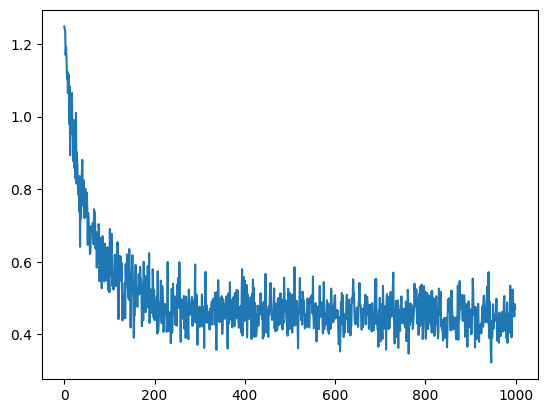

In [32]:
vocab_size = 27
char_embedding_size = 2
block_size = 3
hidden_layer_size = 100
learning_rate = 0.1
epochs = 1000
batch_size = 32

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size)

Final train loss:  2.2344539165496826
Final Test loss: 2.2245607376098633
Loss to beat: 2.17


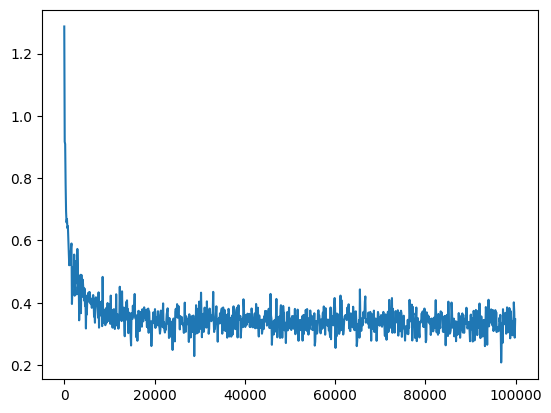

In [33]:
vocab_size = 27
char_embedding_size = 100
block_size = 3
hidden_layer_size = 100
learning_rate = 0.1
epochs = 100_000
batch_size = 64

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size)

In [34]:
vocab_size = 27
char_embedding_size = 200
block_size = 3
hidden_layer_size = 256
learning_rate = 0.1
epochs = 100_000
batch_size = 64
decay_threshold = .2
plot_loss = False

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, decay_threshold=decay_threshold, plot_loss=plot_loss)

Final train loss:  1.6366686820983887
Final Test loss: 2.2604751586914062
Loss to beat: 2.17


In [35]:
vocab_size = 27
char_embedding_size = 50
block_size = 8
hidden_layer_size = 200
learning_rate = 0.1
epochs = 100_000
batch_size = 64


run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=False)

Final train loss:  2.4506874084472656
Final Test loss: 2.4857306480407715
Loss to beat: 2.17


Final train loss:  2.1002399921417236
Final Test loss: 2.241250514984131
Loss to beat: 2.17


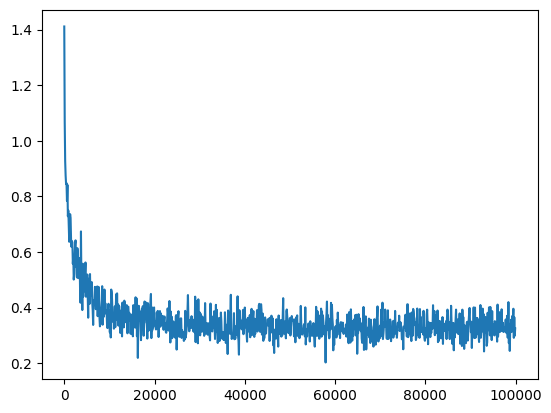

In [36]:
vocab_size = 27
char_embedding_size = 50
block_size = 4
hidden_layer_size = 200
learning_rate = 0.1
epochs = 100_000
batch_size = 64
plot_loss = True

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss)

Final train loss:  2.18050217628479
Final Test loss: 2.2764620780944824
Loss to beat: 2.17


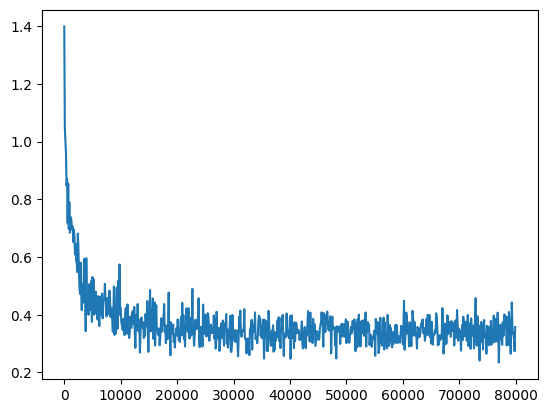

In [ ]:
vocab_size = 27
char_embedding_size = 50
block_size = 4
hidden_layer_size = 200
learning_rate = 0.1
epochs = 80_000
batch_size = 64
plot_loss = True

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss)

Final train loss:  1.9983083009719849
Final Test loss: 2.2168190479278564
Loss to beat: 2.17


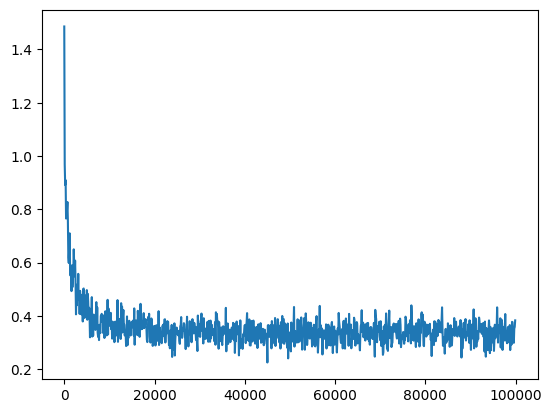

In [39]:
vocab_size = 27
char_embedding_size = 50
block_size = 4
hidden_layer_size = 150
learning_rate = 0.1
epochs = 100_000
batch_size = 64
plot_loss = True

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss)

Final train loss:  2.1035823822021484
Final Test loss: 2.1931233406066895
Loss to beat: 2.17


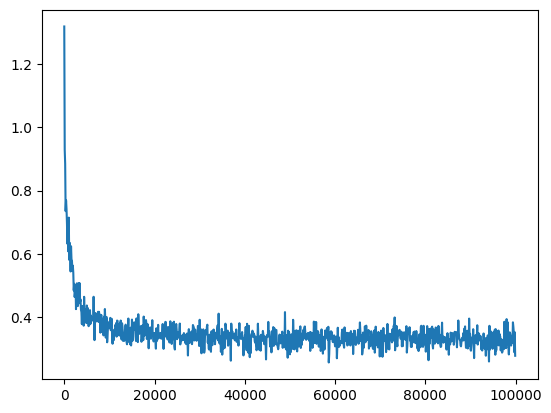

In [ ]:
vocab_size = 27
char_embedding_size = 50
block_size = 4
hidden_layer_size = 128
learning_rate = 0.1
epochs = 100_000
batch_size = 128
plot_loss = True
decay_threshold = 0.3

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss, decay_threshold=decay_threshold)

Final train loss:  2.049302577972412
Final Test loss: 2.2057316303253174
Loss to beat: 2.17


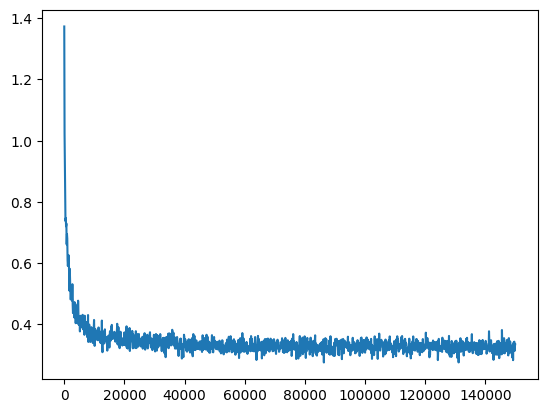

In [48]:
vocab_size = 27
char_embedding_size = 50
block_size = 5
hidden_layer_size = 128
learning_rate = 0.1
epochs = 150_000
batch_size = 256
plot_loss = True
decay_threshold = 0.3

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss, decay_threshold=decay_threshold)

Final train loss:  2.0995354652404785
Final Test loss: 2.221484661102295
Loss to beat: 2.17


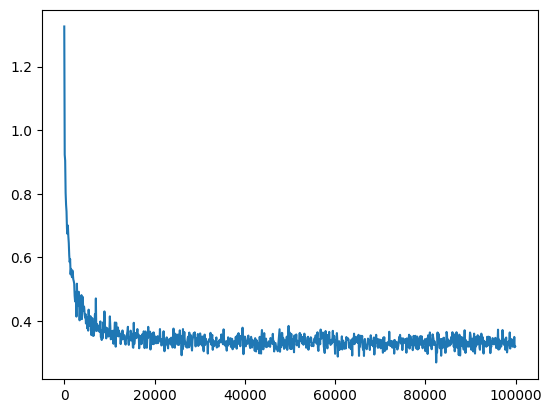

In [55]:
vocab_size = 27
char_embedding_size = 50
block_size = 4
hidden_layer_size = 128
learning_rate = 0.1
epochs = 100_000
batch_size = 256
plot_loss = True
decay_threshold = 0.3

run_experiment(vocab_size= vocab_size, char_embedding_size = char_embedding_size, block_size=block_size, hidden_layer_size=hidden_layer_size, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size, plot_loss=plot_loss, decay_threshold=decay_threshold)